## GSAT trend patterns

In [1]:
# In[1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# %%
# define function
import src.SAT_function_Obs_Fingerprint as data_process
import src.Data_Preprocess as preprocess

In [2]:
# import src.slurm_cluster as scluster
# client, scluster = scluster.init_dask_slurm_cluster()

In [3]:
# Input the observational trend: original, forced and unforced
variable_name = ['60yr', '30yr', '10yr']
period_list = ['1963-2022', '1993-2022', '2013-2022']
dir_in = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIG2/'

HadCRUT5_trend_original_da = {}
for var, prd in zip(variable_name, period_list):
    print(var)
    HadCRUT5_trend_original_da[var] = xr.open_dataset(dir_in + f'Raw_HadCRUT5_MK_trend_1950-2022_sliding.nc').trend.sel(period=prd)
    
HadCRUT5_pvalue_original_da = {}
for var, prd in zip(variable_name, period_list):
    HadCRUT5_pvalue_original_da[var] = xr.open_dataset(dir_in + f'Raw_HadCRUT5_MK_trend_1950-2022_sliding.nc').p_value.sel(period=prd)

dir_in_forced_ICV = '/work/mh0033/m301036/OBS_LPS_revision/docs/data/FIGS5_S6/cesm2_100/'
HadCRUT5_trend_forced_da = {}
HadCRUT5_trend_unforced_da = {}
for var, prd in zip(variable_name, period_list):
    HadCRUT5_trend_forced_da[var] = xr.open_dataset(dir_in_forced_ICV + f'trend_forced_HadCRUT5_annual/forced_HadCRUT5_MMLE_MK_trend_1950-2022_sliding.nc').trend.sel(period=prd)
    HadCRUT5_trend_unforced_da[var] = xr.open_dataset(dir_in_forced_ICV + f'trend_ICV_HadCRUT5_annual/ICV_HadCRUT5_MMLE_MK_trend_1950-2022_sliding.nc').trend.sel(period=prd)

60yr
30yr
10yr


In [4]:
period_list = ['1963-2022', '1993-2022', '2013-2022']
HadCRUT5_pvalue_forced_da = {}
for var, prd in zip(variable_name, period_list):
    HadCRUT5_pvalue_forced_da[var] = xr.open_dataset(dir_in_forced_ICV + f'trend_forced_HadCRUT5_annual/forced_HadCRUT5_MMLE_MK_trend_1950-2022_sliding.nc').p_value.sel(period=prd) 
HadCRUT5_pvalue_unforced_da = {}
for var, prd in zip(variable_name, period_list):
    HadCRUT5_pvalue_unforced_da[var] = xr.open_dataset(dir_in_forced_ICV + f'trend_ICV_HadCRUT5_annual/ICV_HadCRUT5_MMLE_MK_trend_1950-2022_sliding.nc').p_value.sel(period=prd)

In [5]:
HadCRUT5_pvalue_forced_da['60yr']

<xarray.DataArray 'p_value' (lat: 90, lon: 180)>
[16200 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
    period   <U9 '1963-2022'

In [6]:
HadCRUT5_trend_original_da['30yr']

<xarray.DataArray 'trend' (lat: 90, lon: 180)>
[16200 values with dtype=float64]
Coordinates:
  * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
  * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
    period   <U9 '1993-2022'

In [7]:
HadCRUT5_pvalue_forced_da

{'60yr': <xarray.DataArray 'p_value' (lat: 90, lon: 180)>
 [16200 values with dtype=float64]
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
     period   <U9 '1963-2022',
 '30yr': <xarray.DataArray 'p_value' (lat: 90, lon: 180)>
 [16200 values with dtype=float64]
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
     period   <U9 '1993-2022',
 '10yr': <xarray.DataArray 'p_value' (lat: 90, lon: 180)>
 [16200 values with dtype=float64]
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
     period   <U9 '2013-2022'}

In [8]:
# arange data into a list arrocding to the variable name
trend_60yr = {"HadCRUT5 Raw":HadCRUT5_trend_original_da['60yr'], 
            "Forced wrt. MMEM":HadCRUT5_trend_forced_da['60yr'], 
            "Unforced wrt. MMEM":HadCRUT5_trend_unforced_da['60yr']}
p_value_60yr = {"HadCRUT5 Raw":HadCRUT5_pvalue_original_da['60yr'],
            "Forced wrt. MMEM":HadCRUT5_pvalue_forced_da['60yr'],
            "Unforced wrt. MMEM":HadCRUT5_pvalue_unforced_da['60yr']}
trend_30yr = {"HadCRUT5 Raw":HadCRUT5_trend_original_da['30yr'],
            "Forced wrt. MMEM":HadCRUT5_trend_forced_da['30yr'],
            "Unforced wrt. MMEM":HadCRUT5_trend_unforced_da['30yr']}
p_value_30yr = {"HadCRUT5 Raw":HadCRUT5_pvalue_original_da['30yr'],
            "Forced wrt. MMEM":HadCRUT5_pvalue_forced_da['30yr'],
            "Unforced wrt. MMEM":HadCRUT5_pvalue_unforced_da['30yr']}
trend_10yr = {"HadCRUT5 Raw":HadCRUT5_trend_original_da['10yr'],
            "Forced wrt. MMEM":HadCRUT5_trend_forced_da['10yr'],
            "Unforced wrt. MMEM":HadCRUT5_trend_unforced_da['10yr']}
p_value_10yr = {"HadCRUT5 Raw":HadCRUT5_pvalue_original_da['10yr'],
            "Forced wrt. MMEM":HadCRUT5_pvalue_forced_da['10yr'],
            "Unforced wrt. MMEM":HadCRUT5_pvalue_unforced_da['10yr']}
# trend_44yr = {"HadCRUT5 Raw":HadCRUT5_trend_original_da['44yr'],
#             "Forced wrt. MMEM":HadCRUT5_trend_forced_da['44yr'],
#             "Unforced wrt. MMEM":HadCRUT5_trend_unforced_da['44yr']}
# p_value_44yr = {"HadCRUT5 Raw":HadCRUT5_pvalue_original_da['44yr'],
#             "Forced wrt. MMEM":HadCRUT5_pvalue_forced_da['44yr'],
#             "Unforced wrt. MMEM":HadCRUT5_pvalue_unforced_da['44yr']}

### Plotting with the Robinson Projections

In [9]:
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colors import BoundaryNorm
import cartopy.util as cutil
import seaborn as sns
import matplotlib.colors as mcolors
import palettable
#  cmap = mcolors.ListedColormap(palettable.scientific.diverging.Vik_20.mpl_colors)
cmap=mcolors.ListedColormap(palettable.cmocean.diverging.Balance_20.mpl_colors)

In [10]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as mticker
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.gridspec as gridspec

### Plot the Original, Forced, MMEM trend patterns

In [11]:
# reattribute the units for the trend
variable_name = ["HadCRUT5 Raw", "Forced wrt. MMEM", "Unforced wrt. MMEM"]
# degC/60yr, 30yr, 10yr
for i in range(len(variable_name)):
    if i == 0:
        trend_60yr[variable_name[i]] = trend_60yr[variable_name[i]]
        trend_30yr[variable_name[i]] = trend_30yr[variable_name[i]]
        trend_10yr[variable_name[i]] = trend_10yr[variable_name[i]]
    else:
        trend_60yr[variable_name[i]] = trend_60yr[variable_name[i]]
        trend_30yr[variable_name[i]] = trend_30yr[variable_name[i]]
        trend_10yr[variable_name[i]] = trend_10yr[variable_name[i]]

In [12]:
# check the min and max of the trend
for i in range(len(variable_name)):
    print(variable_name[i])
    print(trend_60yr[variable_name[i]].min().values, trend_60yr[variable_name[i]].max().values)
    print(trend_30yr[variable_name[i]].min().values, trend_30yr[variable_name[i]].max().values)
    print(trend_10yr[variable_name[i]].min().values, trend_10yr[variable_name[i]].max().values)

HadCRUT5 Raw
-0.0867393770015186 0.7476344948979627
-0.26864108468383086 1.285722209844854
-2.3276300347578016 2.4680835841972044
Forced wrt. MMEM
-0.0735393854638073 0.5800507551744818
-0.09436627470442838 0.7443253511038033
-0.09266330476304097 0.7308929706955225
Unforced wrt. MMEM
-0.19360666201254206 0.22200078292349668
-0.5767079625583614 0.6168507577098117
-2.4306011546119013 1.787261269986467


In [13]:
# define an asymmetric colormap
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.colors import BoundaryNorm
import cartopy.util as cutil

In [14]:
# Plotting
"""
first column: original trend and p-value
second column: forced trend and p-value
third column: unforced trend and p-value
each row is a different time period
"""
lat = trend_60yr['HadCRUT5 Raw'].lat
lon = trend_60yr['HadCRUT5 Raw'].lon
lat, lon 

(<xarray.DataArray 'lat' (lat: 90)>
 array([-89., -87., -85., -83., -81., -79., -77., -75., -73., -71., -69., -67.,
        -65., -63., -61., -59., -57., -55., -53., -51., -49., -47., -45., -43.,
        -41., -39., -37., -35., -33., -31., -29., -27., -25., -23., -21., -19.,
        -17., -15., -13., -11.,  -9.,  -7.,  -5.,  -3.,  -1.,   1.,   3.,   5.,
          7.,   9.,  11.,  13.,  15.,  17.,  19.,  21.,  23.,  25.,  27.,  29.,
         31.,  33.,  35.,  37.,  39.,  41.,  43.,  45.,  47.,  49.,  51.,  53.,
         55.,  57.,  59.,  61.,  63.,  65.,  67.,  69.,  71.,  73.,  75.,  77.,
         79.,  81.,  83.,  85.,  87.,  89.])
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
     period   <U9 '1963-2022'
 Attributes:
     standard_name:  latitude
     long_name:      latitude
     units:          degrees_north
     axis:           Y,
 <xarray.DataArray 'lon' (lon: 180)>
 array([  0.,   2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  1

In [15]:
p_value_60yr

{'HadCRUT5 Raw': <xarray.DataArray 'p_value' (lat: 90, lon: 180)>
 [16200 values with dtype=float64]
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
     period   <U9 '1963-2022',
 'Forced wrt. MMEM': <xarray.DataArray 'p_value' (lat: 90, lon: 180)>
 [16200 values with dtype=float64]
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
     period   <U9 '1963-2022',
 'Unforced wrt. MMEM': <xarray.DataArray 'p_value' (lat: 90, lon: 180)>
 [16200 values with dtype=float64]
 Coordinates:
   * lat      (lat) float64 -89.0 -87.0 -85.0 -83.0 -81.0 ... 83.0 85.0 87.0 89.0
   * lon      (lon) float64 0.0 2.0 4.0 6.0 8.0 ... 350.0 352.0 354.0 356.0 358.0
     period   <U9 '1963-2022'}

In [16]:
def plot_data_with_significance(trend_data, lats, lons, p_values, GMST_p_values=None, levels=None, extend=None, cmap=None, 
                                 title="", ax=None, show_xticks=False, show_yticks=False):
    """
    Plot the trend spatial pattern using Robinson projection with significance overlaid.

    Parameters:
    - trend_data: 2D numpy array with the trend values.
    - lats, lons: 1D arrays of latitudes and longitudes.
    - p_values: 2D array with p-values for each grid point.
    - GMST_p_values: 2D array with GMST p-values for each grid point.
    - title: Title for the plot.
    - ax: Existing axis to plot on. If None, a new axis will be created.
    - show_xticks, show_yticks: Boolean flags to show x and y axis ticks.
    
    Returns:
    - contour_obj: The contour object from the plot.
    """

    # Create a new figure/axis if none is provided
    if ax is None:
        fig, ax = plt.subplots(figsize=(15, 25), subplot_kw={'projection': ccrs.Robinson()})
        ax.set_global()
  
    # Determine significance mask (where p-values are less than 0.05)
    insignificance_mask = p_values >= 0.05
    # Plotting
    # contour_obj = ax.pcolormesh(lons, lats, trend_data,  cmap='RdBu_r',vmin=-5.0, vmax=5.0, transform=ccrs.PlateCarree(central_longitude=180), shading='auto')
    contour_obj = ax.contourf(lons, lats, trend_data, levels=levels, extend=extend, cmap=cmap, transform=ccrs.PlateCarree(central_longitude=0))

    # Plot significance masks with different hatches
    ax.contourf(lons, lats, insignificance_mask, levels=[0, 0.05, 1.0],hatches=[None,'///'], colors='none', transform=ccrs.PlateCarree())

    ax.coastlines(resolution='110m')
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False,
                      color='gray', alpha=0.15, linestyle='--', linewidth=0.25)

    # Disable labels on the top and right of the plot
    gl.top_labels = False
    gl.right_labels = False

    # Enable labels on the bottom and left of the plot
    gl.bottom_labels = show_xticks
    gl.left_labels = show_yticks
    gl.xformatter = cticker.LongitudeFormatter()
    gl.yformatter = cticker.LatitudeFormatter()
    gl.xlabel_style = {'size': 16}
    gl.ylabel_style = {'size': 16}
    
    if show_xticks:
        gl.bottom_labels = True
    if show_yticks:
        gl.left_labels = True
    
    ax.set_title(title, loc='center',fontsize=20, pad=5.0)

    return contour_obj

In [17]:
# from src.plot_func import *
plt.rcParams.update({
        "figure.dpi": 300,
        "savefig.dpi": 600,      # good for line art; pdf is still vector
        "savefig.transparent": True,

        # font: Myriad-like sans serif, final size 8–9 pt
        "font.family": "sans-serif",
        "font.sans-serif": ["Myriad Pro", "Myriad", "Arial",
                            "Helvetica", "DejaVu Sans"],
        "font.size": 8,          # default text size ~8 pt
        "axes.labelsize": 8,
        "axes.titlesize": 7,     # we’ll usually not use titles in exported figure
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,

        # lines & axes – ensure ≥0.28 pt
        # (Matplotlib linewidth is in points; 0.75–1 is safe)
        "lines.linewidth": 0.8,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.6,
        "ytick.major.width": 0.6,
        "xtick.minor.width": 0.5,
        "ytick.minor.width": 0.5,

        "xtick.direction": "out",
        "ytick.direction": "out",
        "xtick.bottom": True,
        "xtick.top": True,
        "ytick.left": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,

        # grids / spines
        "axes.spines.top": True,
        "axes.spines.right": True,
        "axes.grid": False,
    })

In [18]:
# def plot_data_with_significance(
#     data, lats, lons,
#     p_values,
#     GMST_p_values=None,
#     levels=None, extend=None, cmap=None,
#     title="", ax=None,
#     show_xticks=False, show_yticks=False,
#     alpha_data=1.0,
#     hatch='/////'
# ):
#     if ax is None:
#         fig, ax = plt.subplots(
#             figsize=(6, 3),
#             subplot_kw={'projection': ccrs.Robinson(central_longitude=0)}
#         )
#         ax.set_global()

#     # --- main filled field ---
#     cf = ax.contourf(
#         lons, lats, data,
#         levels=levels, cmap=cmap, extend=extend,
#         transform=ccrs.PlateCarree(),
#         zorder=1, alpha=alpha_data
#     )

#     # --- hatch overlay: here we hatch NON-significant grid points (p >= 0.05) ---
#     #   flip sign if you want to hatch significant ones instead
#     hatch_mask = np.ma.masked_where(p_values < 0.05, p_values)

#     ax.contourf(
#         lons, lats, hatch_mask,
#         levels=[0.05, 1.0],        # one band: 0.05–1
#         colors='none',
#         hatches=[hatch],
#         transform=ccrs.PlateCarree(),
#         zorder=3,                  # above data
#         linewidths=0               # no patch edges
#     )

#     # --- coastlines & grid ---
#     ax.coastlines(resolution='110m', linewidth=0.4)
#     gl = ax.gridlines(
#         draw_labels=True, dms=True, x_inline=False, y_inline=False,
#         colors='gray', alpha=0.4, linestyle='--', linewidth=0.3
#     )
#     gl.top_labels = False
#     gl.right_labels = False
#     gl.bottom_labels = show_xticks
#     gl.left_labels = show_yticks
#     gl.xformatter = cticker.LongitudeFormatter()
#     gl.yformatter = cticker.LatitudeFormatter()
#     gl.xlabel_style = {'size': 6}
#     gl.ylabel_style = {'size': 6}
#     gl.xpadding = 1
#     gl.ypadding = 1

#     ax.set_title(title, loc='center', fontsize=7, pad=3)

#     return cf


/tmp/ipykernel_3144926/1255671266.py:97: MatplotlibDeprecationWarning: The 'extend' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar1 = fig.colorbar(contour_obj_raw, cax=cbar_ax1, orientation='horizontal', extend=extend)
/tmp/ipykernel_3144926/1255671266.py:105: MatplotlibDeprecationWarning: The 'extend' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar2 = fig.colorbar(contour_obj_forced, cax=cbar_ax2, orientation='horizontal', extend=extend)


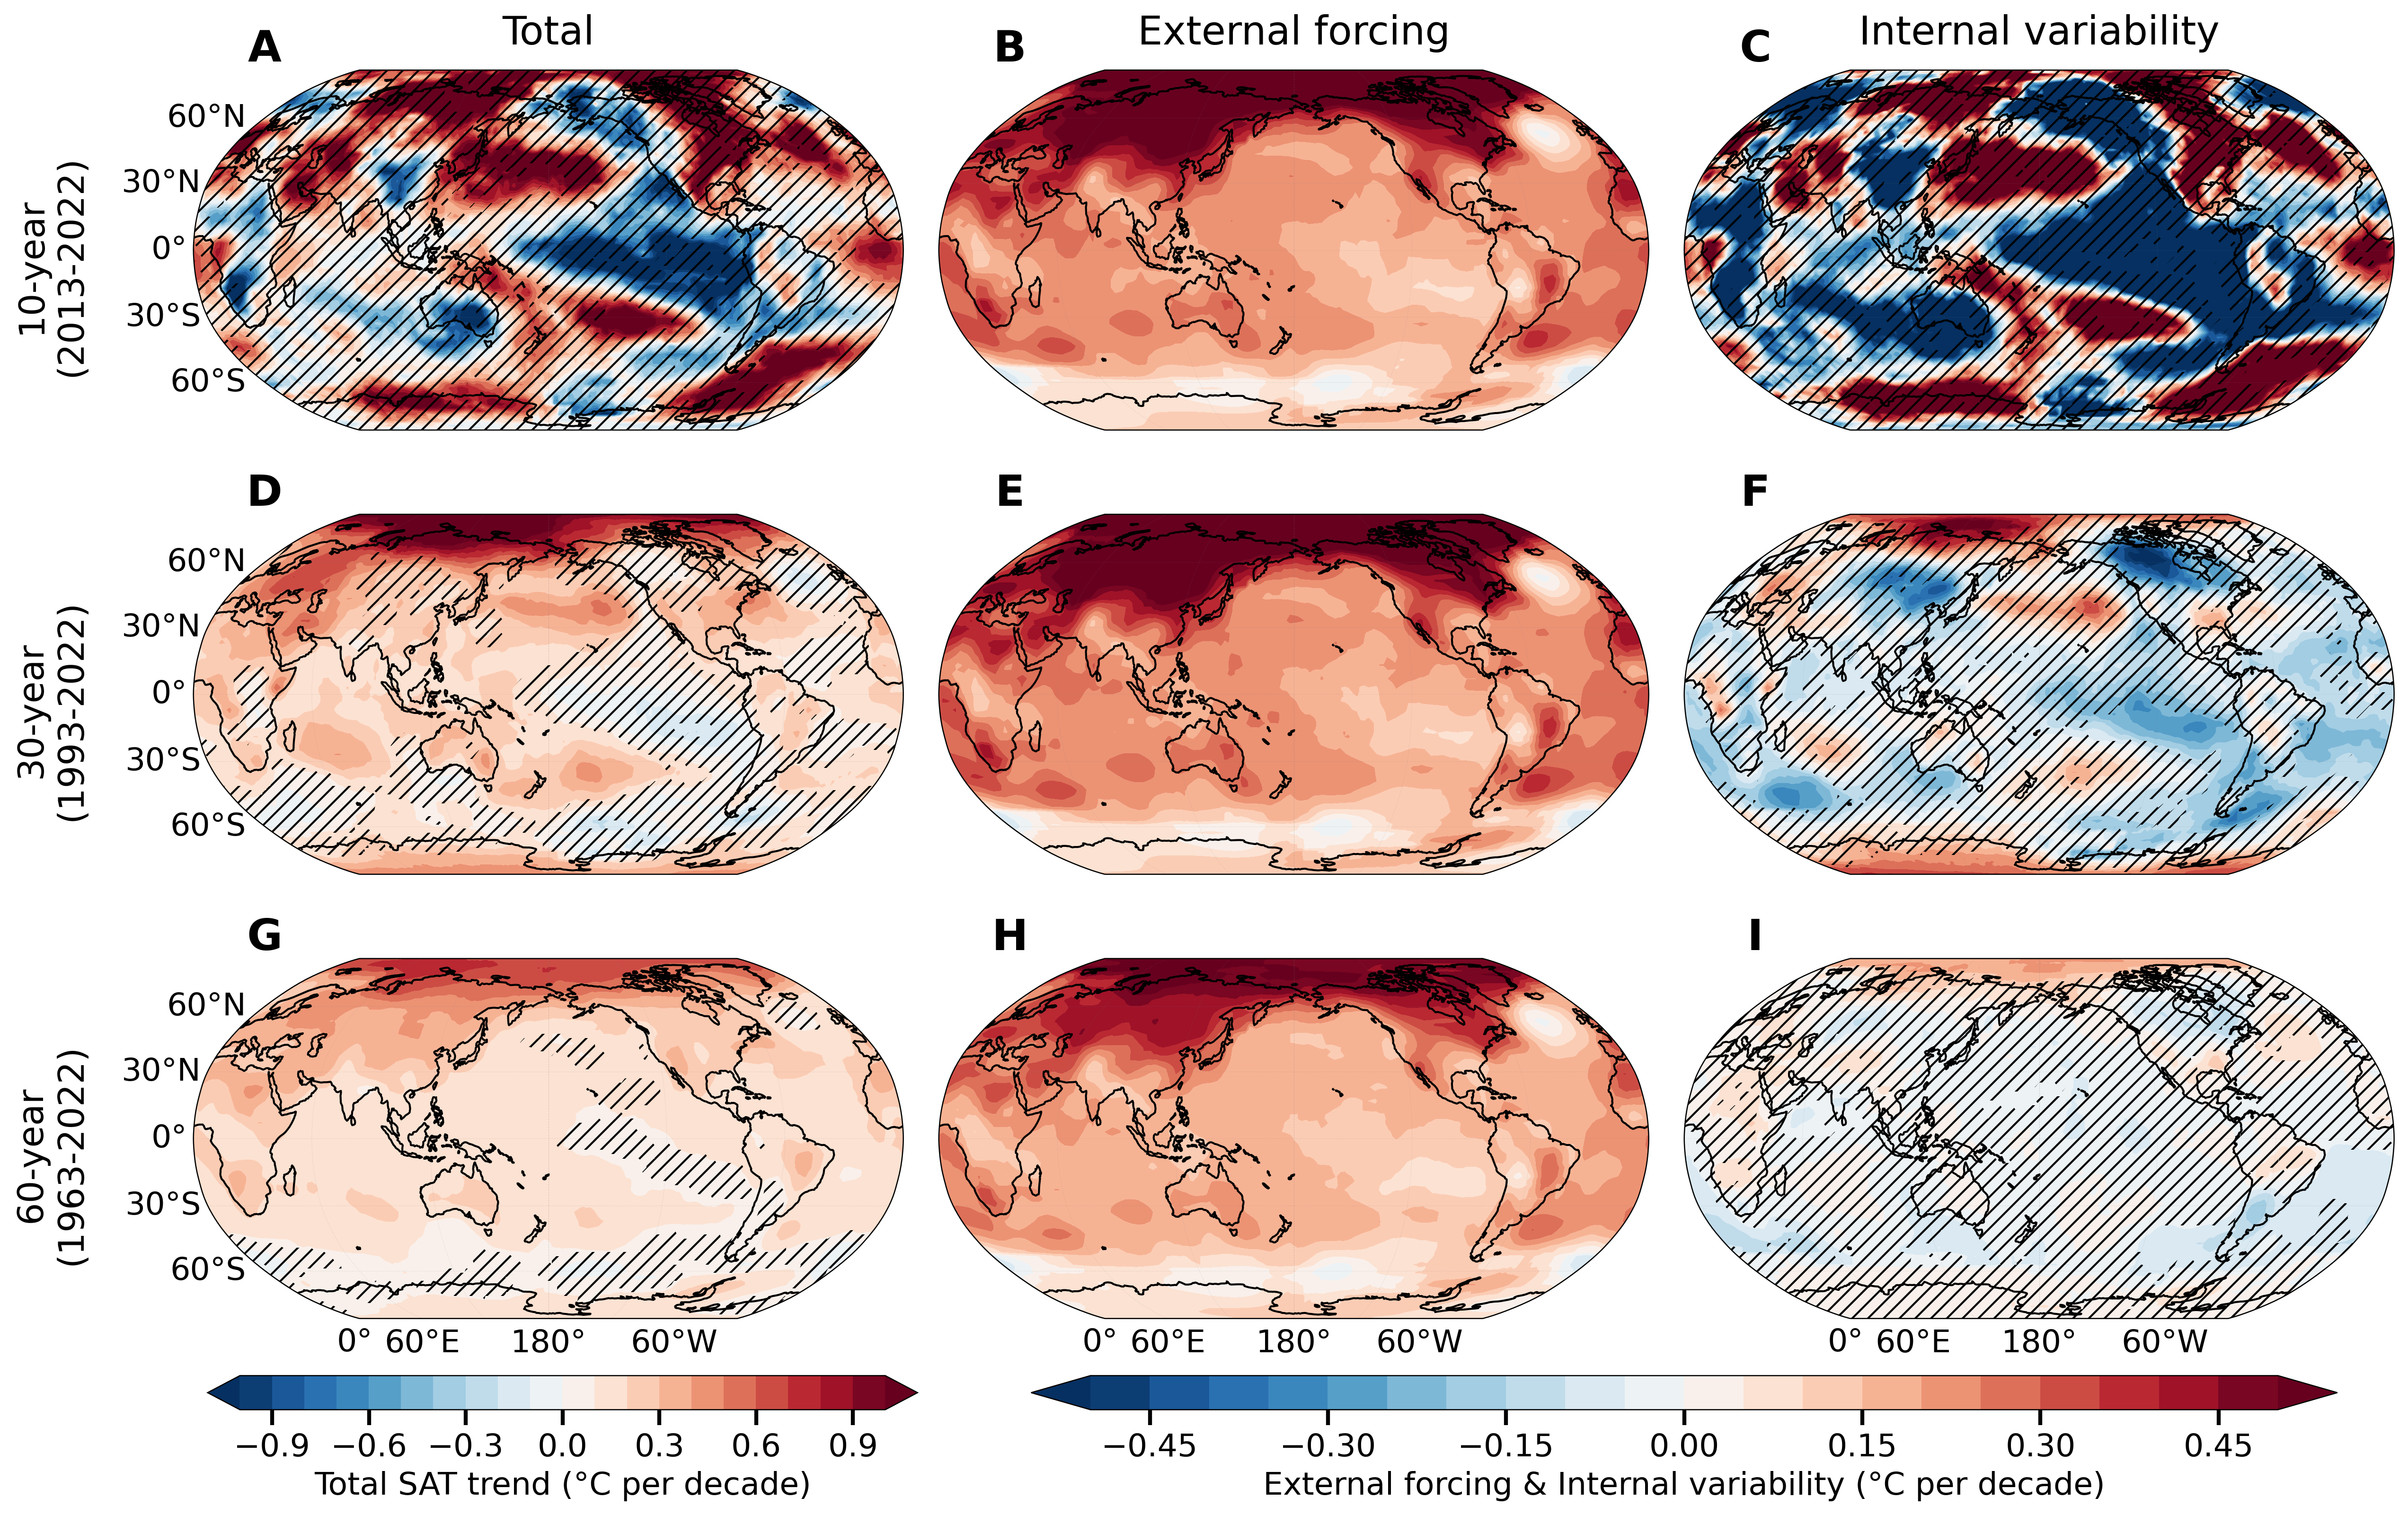

In [ ]:
# titles =["Raw Trend",  "Forced Trend"+ r'$_{wrt.MMEM} $', 
#     "Unforced Trend"+ r'$_{wrt.MMEM} $']
titles =["Total",  "External forcing", "Internal variability"]
titles_rows = ["10-year\n(2013-2022)", "30-year\n(1993-2022)", "60-year\n(1963-2022)"]
titles_left_corner = ["A", "B", "C", "D", "E", "F", "G", "H", "I"]

periods = ["10yr", "30yr", "60yr"]
variable_name = ["HadCRUT5 Raw", "Forced wrt. MMEM", "Unforced wrt. MMEM"]
# Set up intervals for different variables
intervals_raw = np.arange(-1.0, 1.1, 0.1)
intervals = np.arange(-0.5, 0.55, 0.05)

# cmap = mcolors.ListedColormap(palettable.scientific.diverging.Vik_20.mpl_colors)

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(3, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1, 1], wspace=0.05, hspace=0.05)

extend='both'
# Create a 3x3 grid of subplots
axes = {}
contour_obj_raw = None  # For first column colorbar
contour_obj_forced = None  # For second/third column colorbar

for i, period in enumerate(periods):
    for j, var in enumerate(variable_name):
        is_left = j == 0
        is_bottom_row = i >= 2
        
        ax = plt.subplot(gs[i, j], projection=ccrs.Robinson(180))
        ax.set_global()
        axes[i, j] = ax
        if i == 0:
            ax.text(0.5, 1.05, titles[j], va='bottom', ha='center', rotation='horizontal',
                    fontsize=20, transform=ax.transAxes)
        
        # Determine which trend and p-value data to use based on row
        if i == 0:  # 10-year period
            trend_data = trend_10yr[var]
            p_values = p_value_10yr[var]
        elif i == 1:  # 30-year period
            trend_data = trend_30yr[var]
            p_values = p_value_30yr[var]
        else:  # i == 2, 60-year period
            trend_data = trend_60yr[var]
            p_values = p_value_60yr[var]
        
        # Add cyclic points
        trend_with_cyclic, lons_cyclic = cutil.add_cyclic_point(trend_data, coord=lon)
        p_values_with_cyclic, _ = cutil.add_cyclic_point(p_values, coord=lon)
        
        # First column uses intervals_raw, others use intervals
        if j == 0:
            current_levels = intervals_raw
        else:
            current_levels = intervals
        
        contour_obj = plot_data_with_significance(
            trend_with_cyclic, lat, lons_cyclic, p_values_with_cyclic, 
            levels=current_levels, extend=extend,
            cmap='RdBu_r', title=" ", ax=ax, 
            show_xticks=is_bottom_row, show_yticks=is_left
        )
        
        # Store contour objects for colorbars
        if j == 0 and contour_obj_raw is None:
            contour_obj_raw = contour_obj
        elif j > 0 and contour_obj_forced is None:
            contour_obj_forced = contour_obj
        
# for i, period in enumerate(periods):
#     for j, var in enumerate(variable_name):
#         axes[i, j].text(0.1, 1.0, titles_left_corner[i*3+j], va='bottom', ha='center', rotation='horizontal', weight='bold', fontsize=8, transform=axes[i, j].transAxes)
        
# # add text to the left side of the figure weight='bold'
# for i in range(3):
#     axes[i, 0].text(-0.20, 0.15, titles_rows[i], va='bottom', ha='center', rotation=90, fontsize=6, transform=axes[i, 0].transAxes)

# cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02])
# cbar = fig.colorbar(contour_obj, cax=cbar_ax, orientation='horizontal',extend='both')
# # fig.text(0.915, 0.038,'Annual SAT trend ($^\circ$C/decade)',fontsize=18, ha='center', va='bottom')
# cbar.ax.tick_params(labelsize=6)
# cbar.set_label('SAT trend (°C per decade)', fontsize=6)
# cbar.ax.tick_params(direction='out', length=3)  
             
# add the title for each subplot
for i, period in enumerate(periods):
    for j, var in enumerate(variable_name):
        axes[i, j].text(0.1, 1.0, titles_left_corner[i*3+j], va='bottom', ha='center', rotation='horizontal', weight='bold', fontsize=22, transform=axes[i, j].transAxes)
        
# add text to the left side of the figure weight='bold'
for i in range(3):
    axes[i, 0].text(-0.20, 0.15, titles_rows[i], va='bottom', ha='center', rotation=90, fontsize=18, transform=axes[i, 0].transAxes)

# Add two colorbars - one for first column (raw data), one for second/third columns (forced/unforced)
# Colorbar for first column (Total - raw data with larger range)
cbar_ax1 = fig.add_axes([0.13, 0.075, 0.25, 0.02])
cbar1 = fig.colorbar(contour_obj_raw, cax=cbar_ax1, orientation='horizontal', extend=extend)
cbar1.ax.tick_params(labelsize=16)
cbar1.set_label('Total SAT trend (°C per decade)', fontsize=16)
cbar1.ax.tick_params(direction='out', length=8, width=2)
cbar1.ax.minorticks_off()

# Colorbar for second and third columns (forced/unforced with smaller range)
cbar_ax2 = fig.add_axes([0.42, 0.075, 0.46, 0.02])
cbar2 = fig.colorbar(contour_obj_forced, cax=cbar_ax2, orientation='horizontal', extend=extend)
cbar2.ax.tick_params(labelsize=16)
cbar2.set_label('External forcing & Internal variability (°C per decade)', fontsize=16)
cbar2.ax.tick_params(direction='out', length=8, width=2)
cbar2.ax.minorticks_off()

figure_output = '/work/mh0033/m301036/OBS_LPS_revision/docs/Figs/FIG2/'
for ext in ("png", "pdf"):
    fig.savefig(figure_output+f"FIG2_update_Apr26.{ext}", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
titles =["Total",  "External forcing", "Internal variability"]
titles_rows = ["10-year\n(2013-2022)", "30-year\n(1993-2022)", "60-year\n(1963-2022)"]
titles_left_corner = ["A", "B", "C", "D", "E", "F", "G", "H", "I"]

periods = ["10yr", "30yr", "60yr"]
variable_name = ["HadCRUT5 Raw", "Forced wrt. MMEM", "Unforced wrt. MMEM"]
intervals = np.arange(-1.0, 1.1, 0.1)
# cmap = mcolors.ListedColormap(palettable.scientific.diverging.Vik_20.mpl_colors)

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(3, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1, 1], wspace=0.05, hspace=0.05)

extend='both'
# Create a 3x3 grid of subplots
axes = {}
for i, period in enumerate(periods):
    for j, var in enumerate(variable_name):
        is_left = j == 0
        is_bottom_row = i >= 2
        
        ax = plt.subplot(gs[i, j], projection=ccrs.Robinson(180))
        ax.set_global()
        axes[i, j] = ax
        if i == 0:
            ax.text(0.5, 1.05, titles[j], va='bottom', ha='center', rotation='horizontal',
                    fontsize=20, transform=ax.transAxes)
        
        if i == 0 and j < 2:
            # Add cyclic points
            trend_data = trend_10yr[var]
            p_values = p_value_10yr[var]
            trend_with_cyclic, lons_cyclic = cutil.add_cyclic_point(trend_data, coord=lon)
            p_values_with_cyclic, lons_cyclic = cutil.add_cyclic_point(p_values, coord=lon)
            contour_obj = plot_data_with_significance(trend_with_cyclic, lat, lons_cyclic, p_values_with_cyclic, 
                                                       levels=intervals, extend=extend,
                                                       cmap='RdBu_r', title=" ", ax=ax, show_xticks = is_bottom_row, show_yticks = is_left)
        elif i == 1 and j < 2:
            trend_data = trend_30yr[var]
            p_values = p_value_30yr[var]
            trend_with_cyclic, lons_cyclic = cutil.add_cyclic_point(trend_data, coord=lon)
            p_values_with_cyclic, lons_cyclic = cutil.add_cyclic_point(p_values, coord=lon)
            
            contour_obj1 = plot_data_with_significance(trend_with_cyclic, lat, lons_cyclic, p_values_with_cyclic, 
                                                        levels=intervals,extend=extend,
                                                        cmap='RdBu_r', title=" ", ax=ax, show_xticks = is_bottom_row, show_yticks = is_left)
        else:
            trend_data = trend_60yr[var]
            p_values = p_value_60yr[var]
            trend_with_cyclic, lons_cyclic = cutil.add_cyclic_point(trend_data, coord=lon)
            p_values_with_cyclic, lons_cyclic = cutil.add_cyclic_point(p_values, coord=lon)
            
            contour_obj2 = plot_data_with_significance(trend_with_cyclic, lat, lons_cyclic, p_values_with_cyclic, 
                                                        levels=intervals, extend=extend,
                                                        cmap='RdBu_r', title=" ", ax=ax, show_xticks = is_bottom_row, show_yticks = is_left)
        
        if i ==0 and j == 2:
            trend_da_10yr = trend_10yr[var]
            p_values = p_value_10yr[var]
            
            trend_10yr_cyclic, lons_cyclic = cutil.add_cyclic_point(trend_da_10yr, coord=lon)
            p_values_with_cyclic, _ = cutil.add_cyclic_point(p_values, coord=lon)
            contour_obj3 = plot_data_with_significance(trend_10yr_cyclic, lat, lons_cyclic, p_values_with_cyclic,
                                                        levels=intervals, extend=extend,
                                                        cmap='RdBu_r', title=" ", ax=ax, show_xticks = is_bottom_row, show_yticks = is_left)
        elif i == 1 and j == 2:
            trend_da_30yr = trend_30yr[var]
            p_values_30yr = p_value_30yr[var]
            p_values_with_cyclic, lons_cyclic = cutil.add_cyclic_point(p_values_30yr, coord=lon)
            trend_30yr_cyclic, lons_cyclic = cutil.add_cyclic_point(trend_da_30yr, coord=lon)
            contour_obj4 = plot_data_with_significance(trend_30yr_cyclic, lat, lons_cyclic, p_values_with_cyclic,
                                                        levels=intervals, extend=extend,
                                                        cmap='RdBu_r', title=" ", ax=ax, show_xticks = is_bottom_row, show_yticks = is_left)
        elif i == 2 and j == 2:
            trend_da_60yr = trend_60yr[var]
            p_values_60yr  = p_value_60yr[var]
            p_values_with_cyclic, lons_cyclic = cutil.add_cyclic_point(p_values_60yr, coord=lon)
            trend_60yr_cyclic, lons_cyclic = cutil.add_cyclic_point(trend_da_60yr, coord=lon)
            
            contour_obj5 = plot_data_with_significance(trend_60yr_cyclic, lat, lons_cyclic, p_values_with_cyclic,
                                                        levels=intervals, extend=extend,
                                                        cmap='RdBu_r', title=" ", ax=ax, show_xticks = is_bottom_row, show_yticks = is_left)
        
# for i, period in enumerate(periods):
#     for j, var in enumerate(variable_name):
#         axes[i, j].text(0.1, 1.0, titles_left_corner[i*3+j], va='bottom', ha='center', rotation='horizontal', weight='bold', fontsize=8, transform=axes[i, j].transAxes)
        
# # add text to the left side of the figure weight='bold'
# for i in range(3):
#     axes[i, 0].text(-0.20, 0.15, titles_rows[i], va='bottom', ha='center', rotation=90, fontsize=6, transform=axes[i, 0].transAxes)

# cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02])
# cbar = fig.colorbar(contour_obj, cax=cbar_ax, orientation='horizontal',extend='both')
# # fig.text(0.915, 0.038,'Annual SAT trend ($^\circ$C/decade)',fontsize=18, ha='center', va='bottom')
# cbar.ax.tick_params(labelsize=6)
# cbar.set_label('SAT trend (°C per decade)', fontsize=6)
# cbar.ax.tick_params(direction='out', length=3)  
             
# add the title for each subplot
for i, period in enumerate(periods):
    for j, var in enumerate(variable_name):
        axes[i, j].text(0.1, 1.0, titles_left_corner[i*3+j], va='bottom', ha='center', rotation='horizontal', weight='bold', fontsize=22, transform=axes[i, j].transAxes)
        
# add text to the left side of the figure weight='bold'
for i in range(3):
    axes[i, 0].text(-0.20, 0.15, titles_rows[i], va='bottom', ha='center', rotation=90, fontsize=18, transform=axes[i, 0].transAxes)

cbar_ax = fig.add_axes([0.2, 0.075, 0.6, 0.02])
cbar = fig.colorbar(contour_obj, cax=cbar_ax, orientation='horizontal',extend= extend)
# fig.text(0.915, 0.038,'Annual SAT trend ($^\circ$C/decade)',fontsize=18, ha='center', va='bottom')
cbar.ax.tick_params(labelsize=18)
cbar.set_label('SAT trend (°C per decade)', fontsize=18)
cbar.ax.tick_params(direction='out', length=8, width=2)  
# remove the minor ticks from the bar labels
cbar.ax.minorticks_off()

figure_output = '/work/mh0033/m301036/OBS_LPS_revision/docs/Figs/FIG2/'
for ext in ("png", "pdf"):
    fig.savefig(figure_output+f"FIG2_update_07Jan.{ext}", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(1, 1, width_ratios=[1], height_ratios=[1], wspace=0.05, hspace=0.05)
ax = plt.subplot(gs[0, 0], projection=ccrs.Robinson(180))
ax.set_global()

# fallback: define 44-year fields if they do not already exist
if "trend_44yr" not in globals() or "p_value_44yr" not in globals():
    ds_raw = xr.open_dataset(dir_in + "Raw_HadCRUT5_MK_trend_1950-2022_sliding.nc")
contour_obj = plot_data_with_significance(trend_with_cyclic, lat, lons_cyclic, p_values_with_cyclic,
                                           levels=intervals_raw, extend=extend,
                                           cmap='RdBu_r', title=" ", ax=ax, show_xticks = True, show_yticks = True)
trend_data = trend_44yr["HadCRUT5 Raw"]
p_values = p_value_44yr["HadCRUT5 Raw"]
trend_with_cyclic, lons_cyclic = cutil.add_cyclic_point(trend_data, coord=lon)
p_values_with_cyclic, lons_cyclic = cutil.add_cyclic_point(p_values, coord=lon)
contour_obj = plot_data_with_significance(trend_with_cyclic, lat, lons_cyclic, p_values_with_cyclic,
                                           levels=intervals, extend=extend,
                                           cmap='RdBu_r', title=" ", ax=ax, show_xticks = True, show_yticks = True)
ax.text(0.1, 1.0, "A", va='bottom', ha='center', rotation='horizontal', weight='bold', fontsize=20, transform=ax.transAxes)
ax.text(-0.20, 0.15, "Satellite era\n(1979-2022)", va='bottom', ha='center', rotation=90, fontsize=20,  transform=ax.transAxes)    
cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.02])
cbar = fig.colorbar(contour_obj, cax=cbar_ax, orientation='horizontal',extend= extend)
# fig.text(0.915, 0.038,'Annual SAT trend ($^\circ$C/decade)',fontsize=18, ha='center', va='bottom')
cbar.ax.tick_params(labelsize=18)
cbar.set_label('SAT trend (°C per decade)', fontsize=20)
cbar.ax.tick_params(direction='out', length=8, width=2)  
# remove the minor ticks from the bar labels
cbar.ax.minorticks_off()    
figure_output = '/work/mh0033/m301036/OBS_LPS_revision/docs/Figs/'
for ext in ("png", "pdf", "eps"):
    fig.savefig(figure_output+f"Fig2_Satellite_era.{ext}", dpi=300, bbox_inches='tight')
plt.show()